In [793]:
import warnings
warnings.filterwarnings("ignore")

In [794]:
import pandas as P

In [795]:
D = P.read_csv ("RE PP.csv")

In [796]:
print(D.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Garage', 'Age', 'Location', 'Price'], dtype='object')


In [797]:
print(D.dtypes)

Area          int64
Bedrooms      int64
Bathrooms     int64
Garage        int64
Age           int64
Location     object
Price         int64
dtype: object


In [798]:
print(D.shape)

(9724, 7)


In [799]:
NV = D.isnull ().sum ()
print(NV)

Area         0
Bedrooms     0
Bathrooms    0
Garage       0
Age          0
Location     0
Price        0
dtype: int64


In [800]:
DV = D.duplicated ().sum ()
print(DV)

0


In [801]:
from sklearn.preprocessing import LabelEncoder

In [802]:
LE = LabelEncoder ()

In [803]:
D["Location"] = LE.fit_transform (D["Location"])

In [804]:
print(D.dtypes)

Area         int64
Bedrooms     int64
Bathrooms    int64
Garage       int64
Age          int64
Location     int64
Price        int64
dtype: object


In [805]:
X = D[["Area" , "Bedrooms" , "Bathrooms" , "Garage" , "Age" , "Location"]]
Y = D["Price"]

In [806]:
from sklearn.model_selection import train_test_split

In [807]:
X_Train , X_Test , Y_Train , Y_Test = train_test_split (X , Y , test_size = 0.2 , random_state = 42)

In [808]:
from sklearn.linear_model import LinearRegression

In [809]:
M_1 = LinearRegression ()
F_1 = M_1.fit (X_Train , Y_Train)

In [810]:
PRE_1 = F_1.predict (X_Test)

In [811]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
import numpy as N

In [812]:
R2_1 = r2_score (Y_Test , PRE_1)
print(R2_1 * 100 , "%")
print("\n")
MAE_1 = mean_absolute_error (Y_Test , PRE_1)
print(MAE_1)
print("\n")
MSE_1 = mean_squared_error (Y_Test , PRE_1)
print(MSE_1)
print("\n")
RMSE_1 = N.sqrt (MSE_1)
print(RMSE_1)

99.50499566815688 %


24356.343131009948


804777823.7094102


28368.606305375844


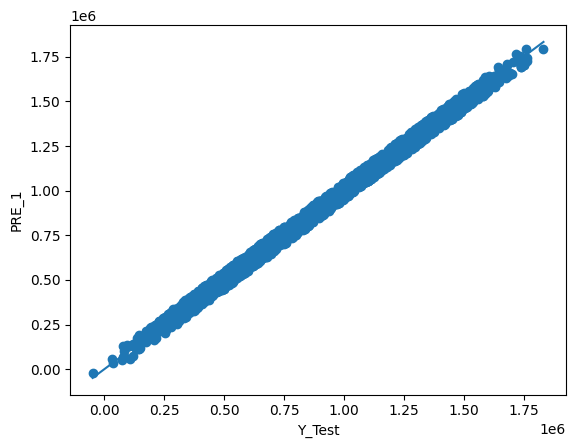

In [813]:
import matplotlib.pyplot as PLOT
PLOT.scatter (Y_Test , PRE_1)
PLOT.plot ([Y_Test.min () , Y_Test.max ()] , [Y_Test.min () , Y_Test.max ()])
PLOT.xlabel ("Y_Test")
PLOT.ylabel ("PRE_1")
PLOT.show ()

In [814]:
print(D.dtypes)

Area         int64
Bedrooms     int64
Bathrooms    int64
Garage       int64
Age          int64
Location     int64
Price        int64
dtype: object


In [815]:
print(D["Area"])
print("\n")
print(D["Bedrooms"])
print("\n")
print(D["Bathrooms"])
print("\n")
print(D["Garage"])
print("\n")
print(D["Age"])
print("\n")
print(D["Location"])
print("\n")
print(D["Price"])

0       1360
1       4272
2       3592
3        966
4       4926
        ... 
9719    2463
9720    4345
9721    3935
9722    1061
9723    2921
Name: Area, Length: 9724, dtype: int64


0       4
1       5
2       1
3       2
4       4
       ..
9719    4
9720    3
9721    1
9722    2
9723    2
Name: Bedrooms, Length: 9724, dtype: int64


0       4
1       4
2       2
3       4
4       4
       ..
9719    1
9720    4
9721    4
9722    1
9723    2
Name: Bathrooms, Length: 9724, dtype: int64


0       1
1       1
2       0
3       1
4       0
       ..
9719    1
9720    0
9721    0
9722    0
9723    1
Name: Garage, Length: 9724, dtype: int64


0       14
1        1
2        5
3        8
4       14
        ..
9719     5
9720    28
9721    20
9722     9
9723     5
Name: Age, Length: 9724, dtype: int64


0       0
1       2
2       1
3       2
4       3
       ..
9719    3
9720    1
9721    1
9722    2
9723    0
Name: Location, Length: 9724, dtype: int64


0        648589
1       1651399
2   

In [816]:
PRE_T_1 = M_1.predict([[4926 , 4 , 4 , 1 , 5 , 3]])
print(PRE_T_1)

[1766795.90952035]


In [817]:
from sklearn.ensemble import RandomForestRegressor

In [818]:
M_2 = RandomForestRegressor ()
F_2 = M_2.fit (X_Train , Y_Train)

In [819]:
PRE_2 = M_2.predict (X_Test)
print(PRE_2)

[ 349539.89 1080908.94 1792990.75 ... 1070961.89 1405044.27 1275651.32]


In [820]:
R2_2 = r2_score (Y_Test , PRE_2)
print(R2_2 * 100 , "%")
print("\n")
MAE_2 = mean_absolute_error (Y_Test , PRE_2)
print(MAE_2)
print("\n")
MSE_2 = mean_squared_error (Y_Test , PRE_2)
print(MSE_2)
print("\n")
RMSE_2 = N.sqrt (MSE_2)
print(RMSE_2)

99.1791751963484 %


29898.381233076263


1334496602.6252897


36530.7624150563


In [821]:
PRE_T_2 = M_2.predict([[4926 , 4 , 4 , 1 , 5 , 3]])
print(PRE_T_2)

[1735128.72]


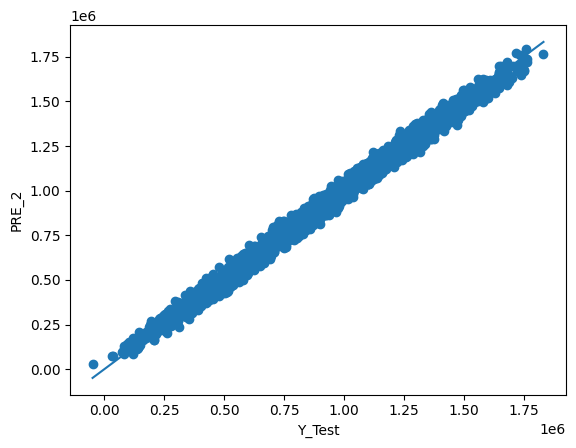

In [822]:
PLOT.scatter (Y_Test , PRE_2)
PLOT.plot ([Y_Test.min () , Y_Test.max ()] , [Y_Test.min () , Y_Test.max ()])
PLOT.xlabel ("Y_Test")
PLOT.ylabel ("PRE_2")
PLOT.show ()

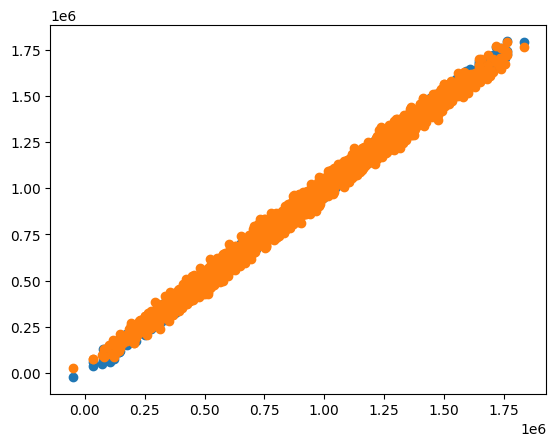

In [823]:
PLOT.scatter (Y_Test , PRE_1)
PLOT.scatter (Y_Test , PRE_2)
PLOT.show ()

In [824]:
SF = D.to_csv ("Real Estate Price Prediction Process.csv" , index = False)